# Task 3: Time Series Analysis
**Internship:** Soft Nexis Technology  
**Intern Name:** Shubham Jaiswal  
**Domain:** Data Science & Machine Learning Using Python  
**Dataset:** Air Passengers (1949-1960)  
**Objective:** Analyze time series data to identify trends, seasonality and forecast future values using ARIMA model.

#### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

print("libraries imported successfully!")

libraries imported successfully!


#### Loading and Inspecting the Dataset
Loading the CSV file, setting Month as index and checking the basic info.

In [2]:
df = pd.read_csv('airline-passengers.csv', parse_dates=['Month'], index_col='Month')
print("Shape:", df.shape)
print("\nMissing Values:", df.isna().sum().sum())

Shape: (144, 1)

Missing Values: 0


In [3]:
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


#### Plotting the Raw Time Series
Visualizing the data to get an overview of the trend and seasonal patterns.

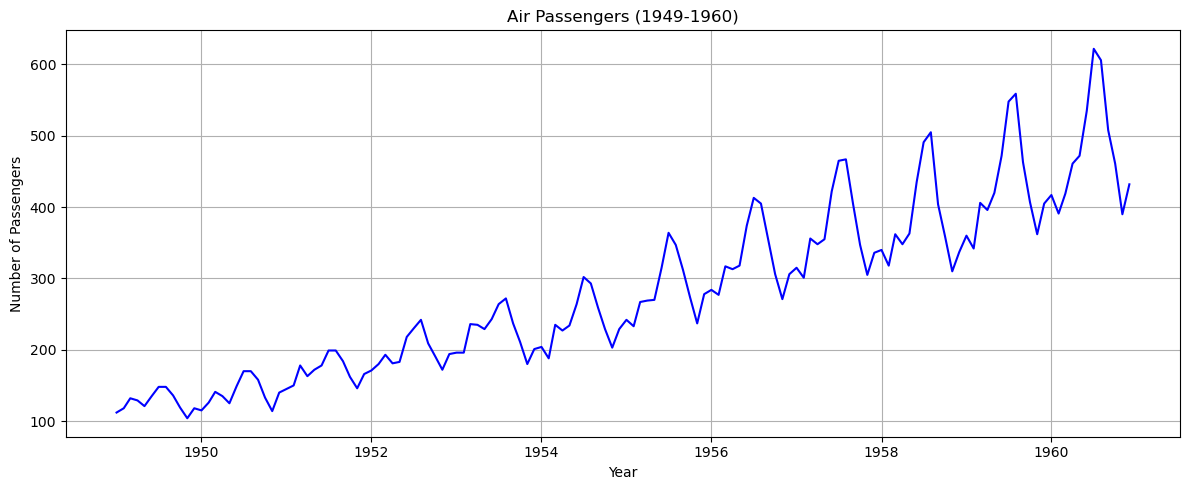

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(df['Passengers'], color='blue')
plt.title('Air Passengers (1949-1960)')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.grid(True)
plt.tight_layout()
plt.savefig('plot1_raw_series.png')
plt.show()

#### Resampling to Quarterly
Converting monthly data to quarterly to observe broader trends.

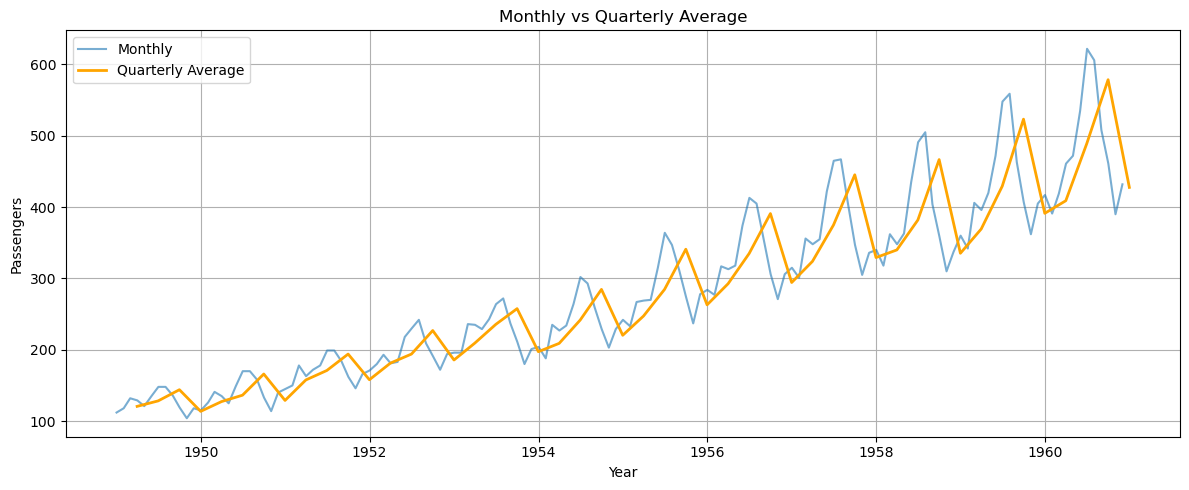

In [5]:
quarterly = df.resample('Q').mean()

plt.figure(figsize=(12, 5))
plt.plot(df['Passengers'], label='Monthly', alpha=0.6)
plt.plot(quarterly['Passengers'], label='Quarterly Average', linewidth=2, color='orange')
plt.title('Monthly vs Quarterly Average')
plt.xlabel('Year')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('plot2_quarterly.png')
plt.show()

### Step 1: Trend & Seasonality Decomposition
Breaking the data into Trend, Seasonality and Residual components using multiplicative model.

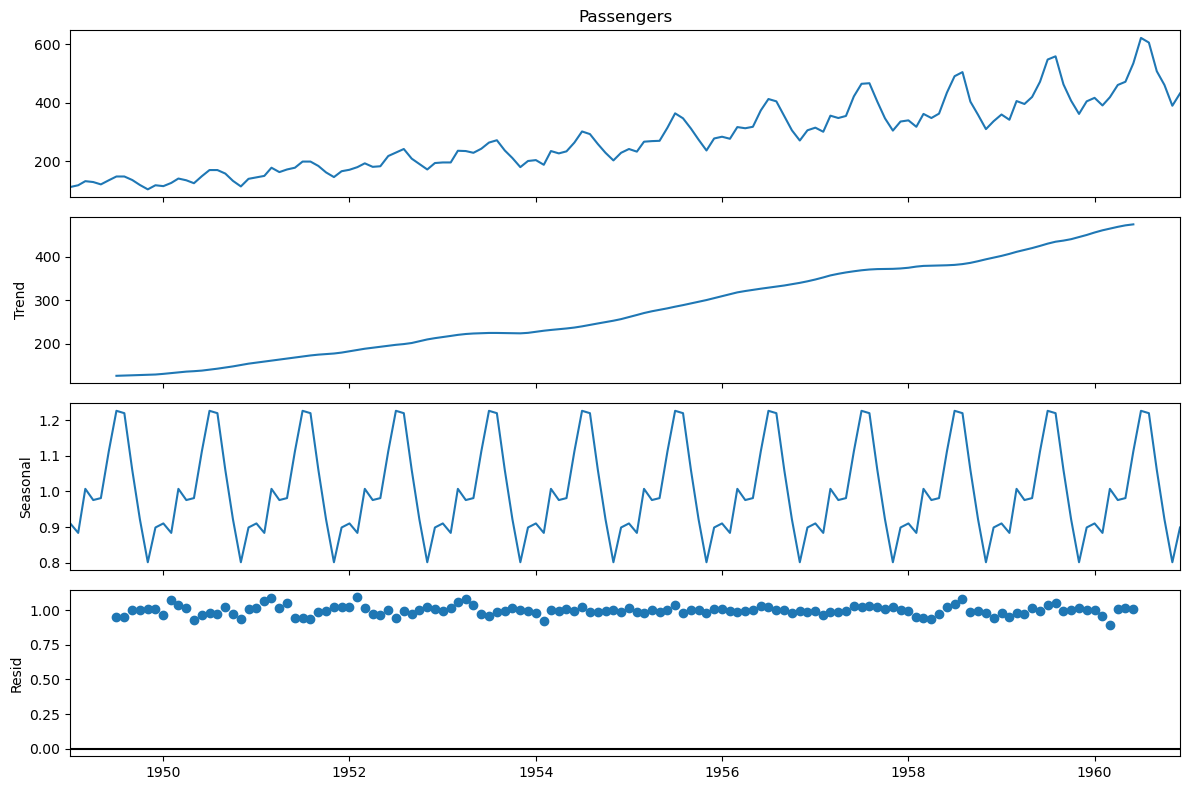

In [6]:
decomposition = seasonal_decompose(df['Passengers'], model='multiplicative')
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.savefig('plot3_decomposition.png')
plt.show()

### Step 2: Moving Averages
Calculating 6-month and 12-month moving averages to smooth out fluctuations and highlight the trend.

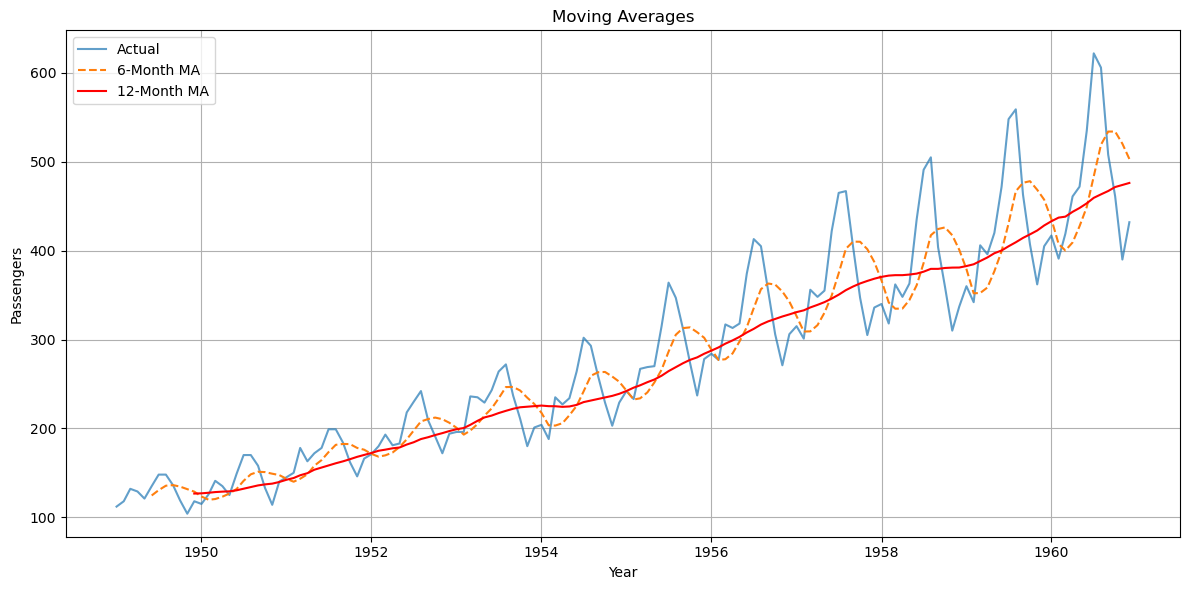

In [7]:
df['MA_6'] = df['Passengers'].rolling(window=6).mean()
df['MA_12'] = df['Passengers'].rolling(window=12).mean()

plt.figure(figsize=(12, 6))
plt.plot(df['Passengers'], label='Actual', alpha=0.7)
plt.plot(df['MA_6'], label='6-Month MA', linestyle='--')
plt.plot(df['MA_12'], label='12-Month MA', color='red')
plt.title('Moving Averages')
plt.xlabel('Year')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('plot4_moving_averages.png')
plt.show()

### Step 3: ARIMA Forecasting
Splitting data into train and test sets, fitting the ARIMA model and forecasting the last 12 months.

In [8]:
train = df['Passengers'].iloc[:-12]
test = df['Passengers'].iloc[-12:]

model = ARIMA(train, order=(2, 1, 1), seasonal_order=(1, 1, 1, 12))
result = model.fit()

forecast = result.forecast(steps=12)
rmse = np.sqrt(mean_squared_error(test, forecast))
print(f"RMSE: {rmse:.2f} passengers")

RMSE: 21.17 passengers


### Step 4: Forecast vs Actual Plot
Comparing the forecasted values with the actual test data.

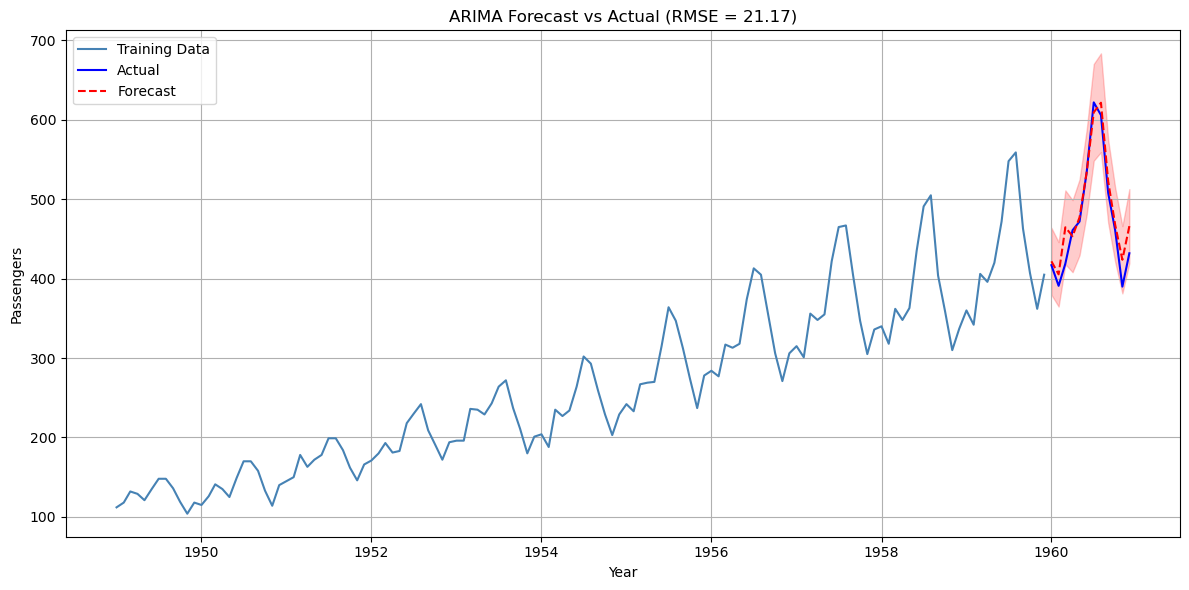

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='steelblue')
plt.plot(test.index, test, label='Actual', color='blue')
plt.plot(test.index, forecast, label='Forecast', color='red', linestyle='--')
plt.fill_between(test.index, forecast * 0.9, forecast * 1.1, alpha=0.2, color='red')
plt.title(f'ARIMA Forecast vs Actual (RMSE = {rmse:.2f})')
plt.xlabel('Year')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('plot5_forecast.png')
plt.show()

### Key Insights & Conclusions

In [10]:
print("===== Key Insights =====")
print(f"Total Records: {len(df)} months (1949-1960)")
print(f"Min Passengers: {df['Passengers'].min()}")
print(f"Max Passengers: {df['Passengers'].max()}")
print(f"Overall Growth: {((df['Passengers'].iloc[-1] - df['Passengers'].iloc[0]) / df['Passengers'].iloc[0] * 100):.1f}%")
print(f"RMSE: {rmse:.2f} passengers")

===== Key Insights =====
Total Records: 144 months (1949-1960)
Min Passengers: 104
Max Passengers: 622
Overall Growth: 285.7%
RMSE: 21.17 passengers


### Saving the Final Dataset

In [11]:
df.to_csv('airline_passengers_final.csv')
print("Dataset saved successfully!")

Dataset saved successfully!
